In [1]:
# Basic dependencies
from qiskit import IBMQ, schedule, QuantumCircuit
import qiskit.pulse as pulse
from qiskit.circuit import QuantumCircuit, Gate
from qiskit.tools.monitor import job_monitor

from utility import *
from constant import *
from unitary_gate import *

import json
import numpy as np
import random
import matplotlib.pyplot as plt

if not IBMQ.active_account():
    IBMQ.load_account()
    
# We'll be using ibm_oslo, qubit 0 as the most suitable options that is currently available
provider = IBMQ.get_provider(hub='ibm-q', group='open', project='main')
backend = provider.get_backend('ibm_oslo')

%config InlineBackend.figure_formats = ['svg']

In [2]:
f = open('zo.json')
zo = json.load(f)
g = open('ot.json')
ot = json.load(g)

zo, ot

({'x_amp': 0.17300039603239967,
  'sx_amp': 0.08712462224930756,
  'dur': 160,
  'beta': 0.21469611947135928},
 {'x_amp': 0.13851295817644882, 'sx_amp': None, 'dur': 160, 'beta': 0})

In [3]:
# Initialize pulse update cycle
ot['x_amp'] = None
ot['dur'] = 208
ot['sx_amp'] = None
ot['beta'] = 0

with open('ot.json', 'w') as g:
    json.dump(ot, g)

In [4]:
drive_freq = backend.configuration().hamiltonian['vars'][f'wq{QUBIT}']/(2*np.pi)
anhar = (backend.properties().qubits[QUBIT][3].value)*1e9

def g01(theta, phi):
    with pulse.build(backend=backend) as g01:
        pulse.set_frequency(drive_freq, pulse.drive_channel(QUBIT))
        with pulse.phase_offset(phi, pulse.drive_channel(QUBIT)):
            pulse.play(pulse.Drag(zo['dur'], (theta*zo['x_amp'])/pi, zo['dur']/4, zo['beta'], 
                                  r'$\mathcal{G}^{01}$'+f'({round(theta, 2)}, {round(phi, 2)})'),
                       pulse.drive_channel(QUBIT))
    return g01

def g12(amp, phi):
    with pulse.build(backend=backend) as g12:
        pulse.set_frequency(drive_freq+anhar, pulse.drive_channel(QUBIT))
        with pulse.phase_offset(phi, pulse.drive_channel(QUBIT)):
            pulse.play(pulse.Drag(ot['dur'], amp, ot['dur']/4, ot['beta'],
                                 r'$\mathcal{G}^{12}$'+f'({round(amp, 2)})'),
                       pulse.drive_channel(QUBIT))
    return g12

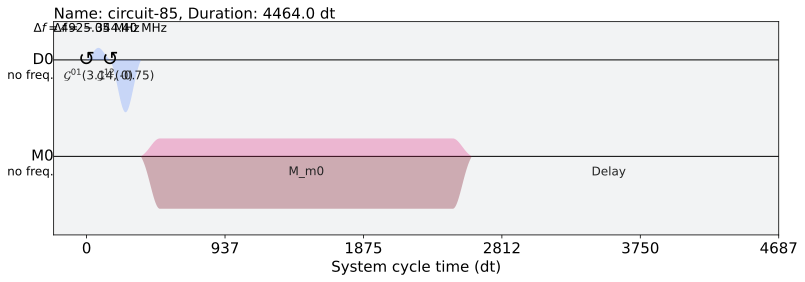

In [5]:
theta_12_x = Gate(r'$\theta_x^{(12)}$', 1, [])
pi_01_x = Gate(r'$\pi_x^{(01)}$', 1, [])

package = []
amps = np.linspace(-0.75, 0.75, 100)

for a in amps:
    amp12 = QuantumCircuit(1, 1)
    amp12.append(pi_01_x, [0])
    amp12.append(theta_12_x, [0])
    amp12.measure(0, 0)
    amp12.add_calibration(pi_01_x, (0,), g01(pi, 0), [])
    amp12.add_calibration(theta_12_x, (0,), g12(a, 0), [])
    package.append(amp12)
    
schedule(package[0], backend=backend).draw()

In [6]:
amp12_job = backend.run(package, meas_level=1, meas_return='avg', shots=2**14)
print(amp12_job.job_id())
job_monitor(amp12_job)

63df60f0f33812cca87248e3
Job Status: job has successfully run


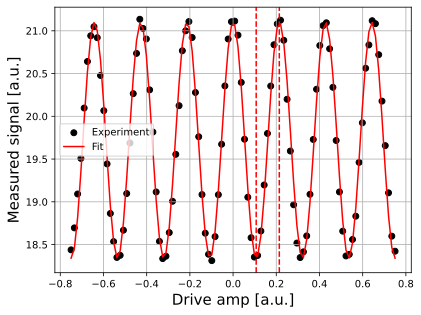

In [9]:
#amp12_job = backend.retrieve_job('63c88f096e244fb75dd09421')

amp12 = DataAnalysis(experiment=amp12_job)
amp12.retrieve_data(average=True)

fit_params, y_fit = fit_function(amps,
                                 amp12.IQ_data, 
                                 lambda x, A, B, drive_period, phi: (A*np.cos(2*np.pi*x/drive_period - phi) + B),
                                 [20, 0, 0.2, 0])

plt.scatter(amps, amp12.IQ_data, color='black', label="Experiment")
plt.plot(amps, y_fit, color='red', label="Fit")

drive_period = fit_params[2]
x_amp = abs(drive_period)/2

plt.axvline(drive_period/2, color='red', linestyle='--')
plt.axvline(drive_period, color='red', linestyle='--')
plt.annotate("", xy=(drive_period, 0), xytext=(drive_period/2,0), arrowprops=dict(arrowstyle="<->", color='red'))
plt.annotate("$\pi$", xy=(drive_period/2-0.03, 0.1), color='red')

plt.xlabel("Drive amp [a.u.]", fontsize=15)
plt.ylabel("Measured signal [a.u.]", fontsize=15)
plt.grid()
plt.legend()
plt.show()

In [10]:
# Update single variable
ot['x_amp'] = x_amp

with open('ot.json', 'w') as g:
    json.dump(ot, g)